# Stationarity and Time Series Preparation in Forecasting 

### Problem Statement:

In time series forecasting, models like ARIMA and SARIMA require the data 
to be stationary. Non-stationary series (with trends or seasonality) can 
mislead the model and produce poor forecasts.

### This program demonstrates:

1. How to simulate non-stationary data.
2. Using Augmented Dickey-Fuller (ADF) Test to check stationarity.
3. Different methods to transform non-stationary data into stationary data:
   - Differencing
   - Log Transformation
   - Log + Differencing
4. Decomposition of time series into trend, seasonality, and residuals.
5. Comparing results with both visual plots and statistical tests.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Create a non-stationary series (trend)
np.random.seed(42)
time = np.arange(1, 101)
non_stationary = 50 + 0.5*time + np.random.normal(size=100)
non_stationary

array([50.99671415, 50.8617357 , 52.14768854, 53.52302986, 52.26584663,
       52.76586304, 55.07921282, 54.76743473, 54.03052561, 55.54256004,
       55.03658231, 55.53427025, 56.74196227, 55.08671976, 55.77508217,
       57.43771247, 57.48716888, 59.31424733, 58.59197592, 58.5876963 ,
       61.96564877, 60.7742237 , 61.5675282 , 60.57525181, 61.95561728,
       63.11092259, 62.34900642, 64.37569802, 63.89936131, 64.70830625,
       64.89829339, 67.85227818, 66.48650278, 65.94228907, 68.32254491,
       66.77915635, 68.7088636 , 67.04032988, 68.17181395, 70.19686124,
       71.23846658, 71.17136828, 71.38435172, 71.6988963 , 71.02147801,
       72.28015579, 73.03936123, 75.05712223, 74.84361829, 73.23695984,
       75.82408397, 75.61491772, 75.823078  , 77.61167629, 78.53099952,
       78.93128012, 77.66078248, 78.69078762, 79.83126343, 80.97554513,
       80.02082576, 80.81434102, 80.39366503, 80.80379338, 83.31252582,
       84.35624003, 83.42798988, 85.0035329 , 84.86163603, 84.35

In [3]:
# Create a stationary series (random noise)
stationary = np.random.normal(loc=50, scale=5, size=100)
stationary

array([42.92314629, 47.89677339, 48.28642742, 45.98861365, 49.19357144,
       52.02025428, 59.43092951, 50.87288906, 51.28775195, 49.62777042,
       40.40614392, 49.86743062, 50.30115105, 62.31621056, 49.03819518,
       51.50773671, 49.82644115, 44.15660981, 55.71411407, 53.75966516,
       53.95515974, 45.45306273, 57.01397155, 42.99074469, 52.93428547,
       60.95227813, 45.04731837, 47.16851135, 50.49825683, 47.48262173,
       42.24668284, 50.34281487, 44.68848143, 52.36796215, 45.40287883,
       57.74967203, 46.08373354, 48.38969242, 54.06758609, 43.84567842,
       51.13729967, 56.53571377, 41.96258383, 50.92316929, 51.29941397,
       53.90911436, 43.81524645, 43.39771693, 52.60970783, 51.48492337,
       51.25246425, 51.73224105, 46.59987639, 51.16126849, 51.46536237,
       46.42824291, 59.32887256, 52.3691646 , 44.04348251, 53.28276804,
       45.12659165, 53.93542302, 55.7929779 , 45.89658841, 54.81688065,
       52.06390463, 54.1103008 , 59.48396491, 48.77305942, 46.23

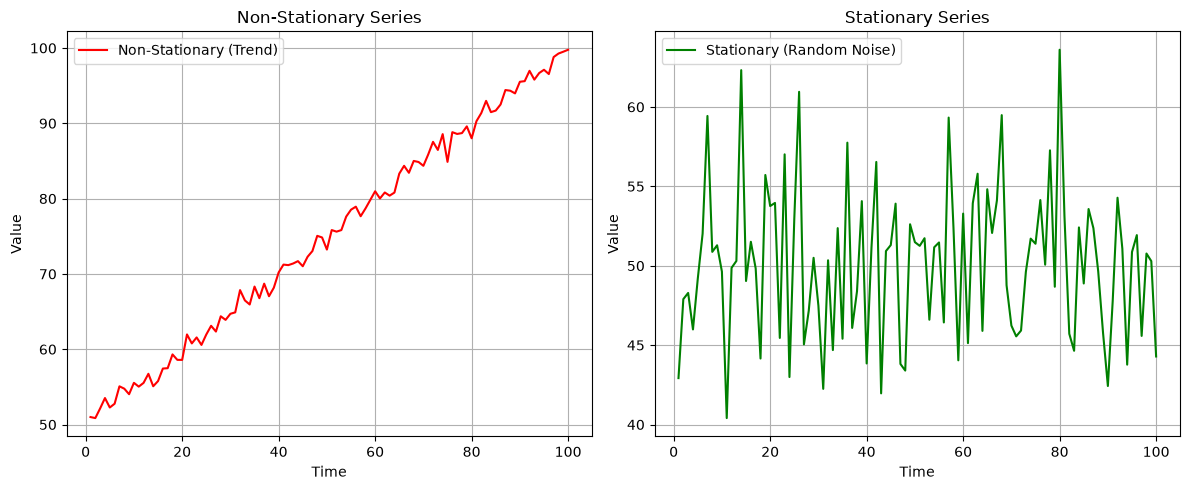

In [4]:
# Plot both
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(time, non_stationary, label="Non-Stationary (Trend)", color='red')
plt.title("Non-Stationary Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(time, stationary, label="Stationary (Random Noise)", color='green')
plt.title("Stationary Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### ADF (Augmented Dickey-Fuller) Test


The ADF test checks if a series is stationary:

•	Null hypothesis (H₀): Series is non-stationary.

•	Alternative hypothesis (H₁): Series is stationary.

If p-value < 0.05, reject H₀ → data is stationary.

In [5]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(non_stationary)
result

C:\Users\asus\AppData\Local\Temp\ipykernel_13904\2613824495.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(non_stationary)


(0.24807855546592517,
 0.9748328625999761,
 4,
 95,
 {'1%': np.float64(-3.5011373281819504),
  '5%': np.float64(-2.8924800524857854),
  '10%': np.float64(-2.5832749307479226)},
 np.float64(252.40566743536075))

In [6]:
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.24807855546592517
p-value: 0.9748328625999761


### Observation
For our stationary series, p-value will be > 0.05 →  Do not reject H₀ → series is non-stationary.

In [8]:
from statsmodels.tsa.stattools import adfuller

result1 = adfuller(stationary)
print("ADF Statistic:", result1[0])
print("p-value:", result1[1])

ADF Statistic: -10.875458876565842
p-value: 1.3352313844030579e-19


C:\Users\asus\AppData\Local\Temp\ipykernel_13904\1676665248.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result1 = adfuller(stationary)


### Observation
For our stationary series, p-value will be < 0.05 →   reject H₀ → series is stationary.

### Making Data Stationary — Differencing
We can apply first-order differencing: subtract each value from the previous one.

In [9]:
# First differencing
diff_series = pd.Series(non_stationary).diff().dropna()
diff_series.head()

1   -0.134978
2    1.285953
3    1.375341
4   -1.257183
5    0.500016
dtype: float64

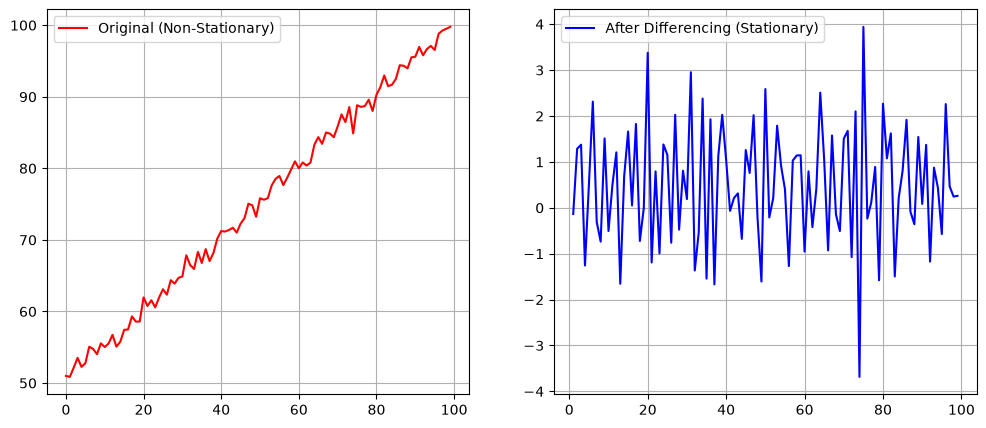

In [10]:
# Plot before and after
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(non_stationary, label="Original (Non-Stationary)", color='red')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(diff_series, label="After Differencing (Stationary)", color='blue')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# ADF test after differencing
result_diff = adfuller(diff_series)
print("After differencing - p-value:", result_diff[1])

After differencing - p-value: 9.019393985742978e-06


C:\Users\asus\AppData\Local\Temp\ipykernel_13904\3566809930.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_diff = adfuller(diff_series)


### Observation
After differencing, the upward trend disappears — the mean fluctuates around zero.
p-value will now be < 0.05 → series is stationary.